In [89]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import util.functions as functions
from models.FNO import CAPE_FNO
import pybamm
import flax

In [90]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
from util.plotting import create_plot_FNO_results, create_plot_voltage
from util.postprocess import filter_anode_cathode

In [91]:
family = "GRF"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
random_seed = 42
test_ratio = 0.1

train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=random_seed)

In [92]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

### Anode data ###
train_cn_anode = np.array(train_data["cn_anode"])
test_cn_anode = np.array(test_data["cn_anode"])
train_c0_anode = np.array(train_data["c0_anode"])
test_c0_anode = np.array(test_data["c0_anode"])
train_D_anode = np.array(train_data["Dan"])
test_D_anode = np.array(test_data["Dan"])

###Cathode data ###
train_cn_cathode = np.array(train_data["cn_cathode"])
test_cn_cathode = np.array(test_data["cn_cathode"])
train_c0_cathode = np.array(train_data["c0_cathode"])
test_c0_cathode = np.array(test_data["c0_cathode"])
train_D_cathode = np.array(train_data["Dca"])
test_D_cathode = np.array(test_data["Dca"])

train_soc = np.array(train_data["soc"])
test_soc = np.array(test_data["soc"])

In [93]:
train_D_anode = normalise_diffusion(train_D_anode).reshape(-1,1)
test_D_anode = normalise_diffusion(test_D_anode).reshape(-1,1)

train_D_cathode = normalise_diffusion(train_D_cathode).reshape(-1,1)
test_D_cathode = normalise_diffusion(test_D_cathode).reshape(-1,1)

In [94]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)

In [95]:
cs_max_a_norm = 1
cs_max_c_norm = 1
cs_min_a_norm = 0
cs_min_c_norm = 0

In [96]:
train_cn_anode, train_cn_cathode, train_mask = filter_anode_cathode(train_cn_anode, train_cn_cathode,
                                                               anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                               cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [97]:
test_cn_anode, test_cn_cathode, test_mask = filter_anode_cathode(test_cn_anode, test_cn_cathode,
                                                               anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                               cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [98]:
train_I = train_I[train_mask]
test_I = test_I[test_mask]
train_c0_anode = train_c0_anode[train_mask]
test_c0_anode = test_c0_anode[test_mask]
train_c0_cathode = train_c0_cathode[train_mask]
test_c0_cathode = test_c0_cathode[test_mask]
train_D_anode = train_D_anode[train_mask]
test_D_anode = test_D_anode[test_mask]
train_D_cathode = train_D_cathode[train_mask]
test_D_cathode = test_D_cathode[test_mask]
train_soc = train_soc[train_mask]
test_soc = test_soc[test_mask]

In [99]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [100]:
X_train_anode, Y_train_anode = preprocess_data(train_I, train_c0_anode, train_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test_anode, Y_test_anode = preprocess_data(test_I, test_c0_anode, test_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)

X_train_cathode, Y_train_cathode = preprocess_data(train_I, train_c0_cathode, train_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test_cathode, Y_test_cathode = preprocess_data(test_I, test_c0_cathode, test_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [101]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
input_channels = X_train_anode.shape[-1]  # should be 4
output_channels = 1
cape_hidden_size = 32

In [102]:
model = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, 
                 fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, 
                 hidden_channels=hidden_channels, output_channels=output_channels)

main_key = jax.random.PRNGKey(random_seed)
# Initialize parameters
dummy_D = jax.random.normal(main_key, (1,1))
params = model.init(main_key, X_train_anode[:1,...], dummy_D)

# Forward pass
out = model.apply(params, X_train_anode[:1,...], dummy_D)

In [103]:
anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_17-11-44.msgpack"
cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_17-35-54.msgpack"

# anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_00-51-44.msgpack"
# cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_01-15-54.msgpack"

params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [104]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 3600

t = np.linspace(0, 1, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [105]:
train_idx = np.random.randint(0, train_c0_anode.shape[0]) + 1
test_idx = np.random.randint(0, test_c0_anode.shape[0]) + 1

In [106]:
print("Train index:", train_idx)
print("Test index:", test_idx)

Train index: 1756
Test index: 828


In [107]:
train_D_anode.shape

(12187, 1)

In [108]:
c_train_true_anode = train_cn_anode[train_idx]
c_train_pred_anode = model.apply(params_anode,X_train_anode[train_idx][None,...], train_D_anode[train_idx][None,...])

c_test_true_anode = test_cn_anode[test_idx]
c_test_pred_anode = model.apply(params_anode,X_test_anode[test_idx][None,...], test_D_anode[test_idx][None,...])

c_train_true_reshaped_anode = c_train_true_anode  # already (20,75)
c_test_true_reshaped_anode = c_test_true_anode   # already (20,75)
c_train_pred_reshaped_anode = remove_padding(c_train_pred_anode, padding_r, padding_t)
c_test_pred_reshaped_anode = remove_padding(c_test_pred_anode, padding_r, padding_t)

In [109]:
c_train_true_cathode = train_cn_cathode[train_idx]
c_train_pred_cathode = model.apply(params_cathode,X_train_cathode[train_idx][None,...], train_D_cathode[train_idx][None,...])

c_test_true_cathode = test_cn_cathode[test_idx]
c_test_pred_cathode = model.apply(params_cathode,X_test_cathode[test_idx][None,...], test_D_cathode[test_idx][None,...])

c_train_true_reshaped_cathode = c_train_true_cathode  # already (20,75)
c_test_true_reshaped_cathode = c_test_true_cathode   # already (20,75)
c_train_pred_reshaped_cathode = remove_padding(c_train_pred_cathode, padding_r, padding_t)
c_test_pred_reshaped_cathode = remove_padding(c_test_pred_cathode, padding_r, padding_t)

In [110]:
c_train_pred_reshaped_anode = jnp.squeeze(c_train_pred_reshaped_anode, axis=(0,-1))  # (20,75)
c_test_pred_reshaped_anode = jnp.squeeze(c_test_pred_reshaped_anode, axis=(0,-1))  # (20,75)

c_train_pred_reshaped_cathode = jnp.squeeze(c_train_pred_reshaped_cathode, axis=(0,-1))  # (20,75)
c_test_pred_reshaped_cathode = jnp.squeeze(c_test_pred_reshaped_cathode, axis=(0,-1))  # (20,75)

In [111]:
c_pred_an_surf = c_test_pred_reshaped_anode[-1,:]
c_pred_ca_surf = c_test_pred_reshaped_cathode[-1,:]

c_true_an_surf = c_test_true_reshaped_anode[-1,:]
c_true_ca_surf = c_test_true_reshaped_cathode[-1,:]

In [112]:
c_train_pred_scaled_anode = c_train_pred_reshaped_anode * cs_max_a
c_test_pred_scaled_anode = c_test_pred_reshaped_anode * cs_max_a

c_test_true_scaled_anode = c_test_true_reshaped_anode * cs_max_a
c_train_true_scaled_anode = c_train_true_reshaped_anode * cs_max_a


c_train_pred_scaled_cathode = c_train_pred_reshaped_cathode * cs_max_c
c_test_pred_scaled_cathode = c_test_pred_reshaped_cathode * cs_max_c

c_test_true_scaled_cathode = c_test_true_reshaped_cathode * cs_max_c
c_train_true_scaled_cathode = c_train_true_reshaped_cathode * cs_max_c

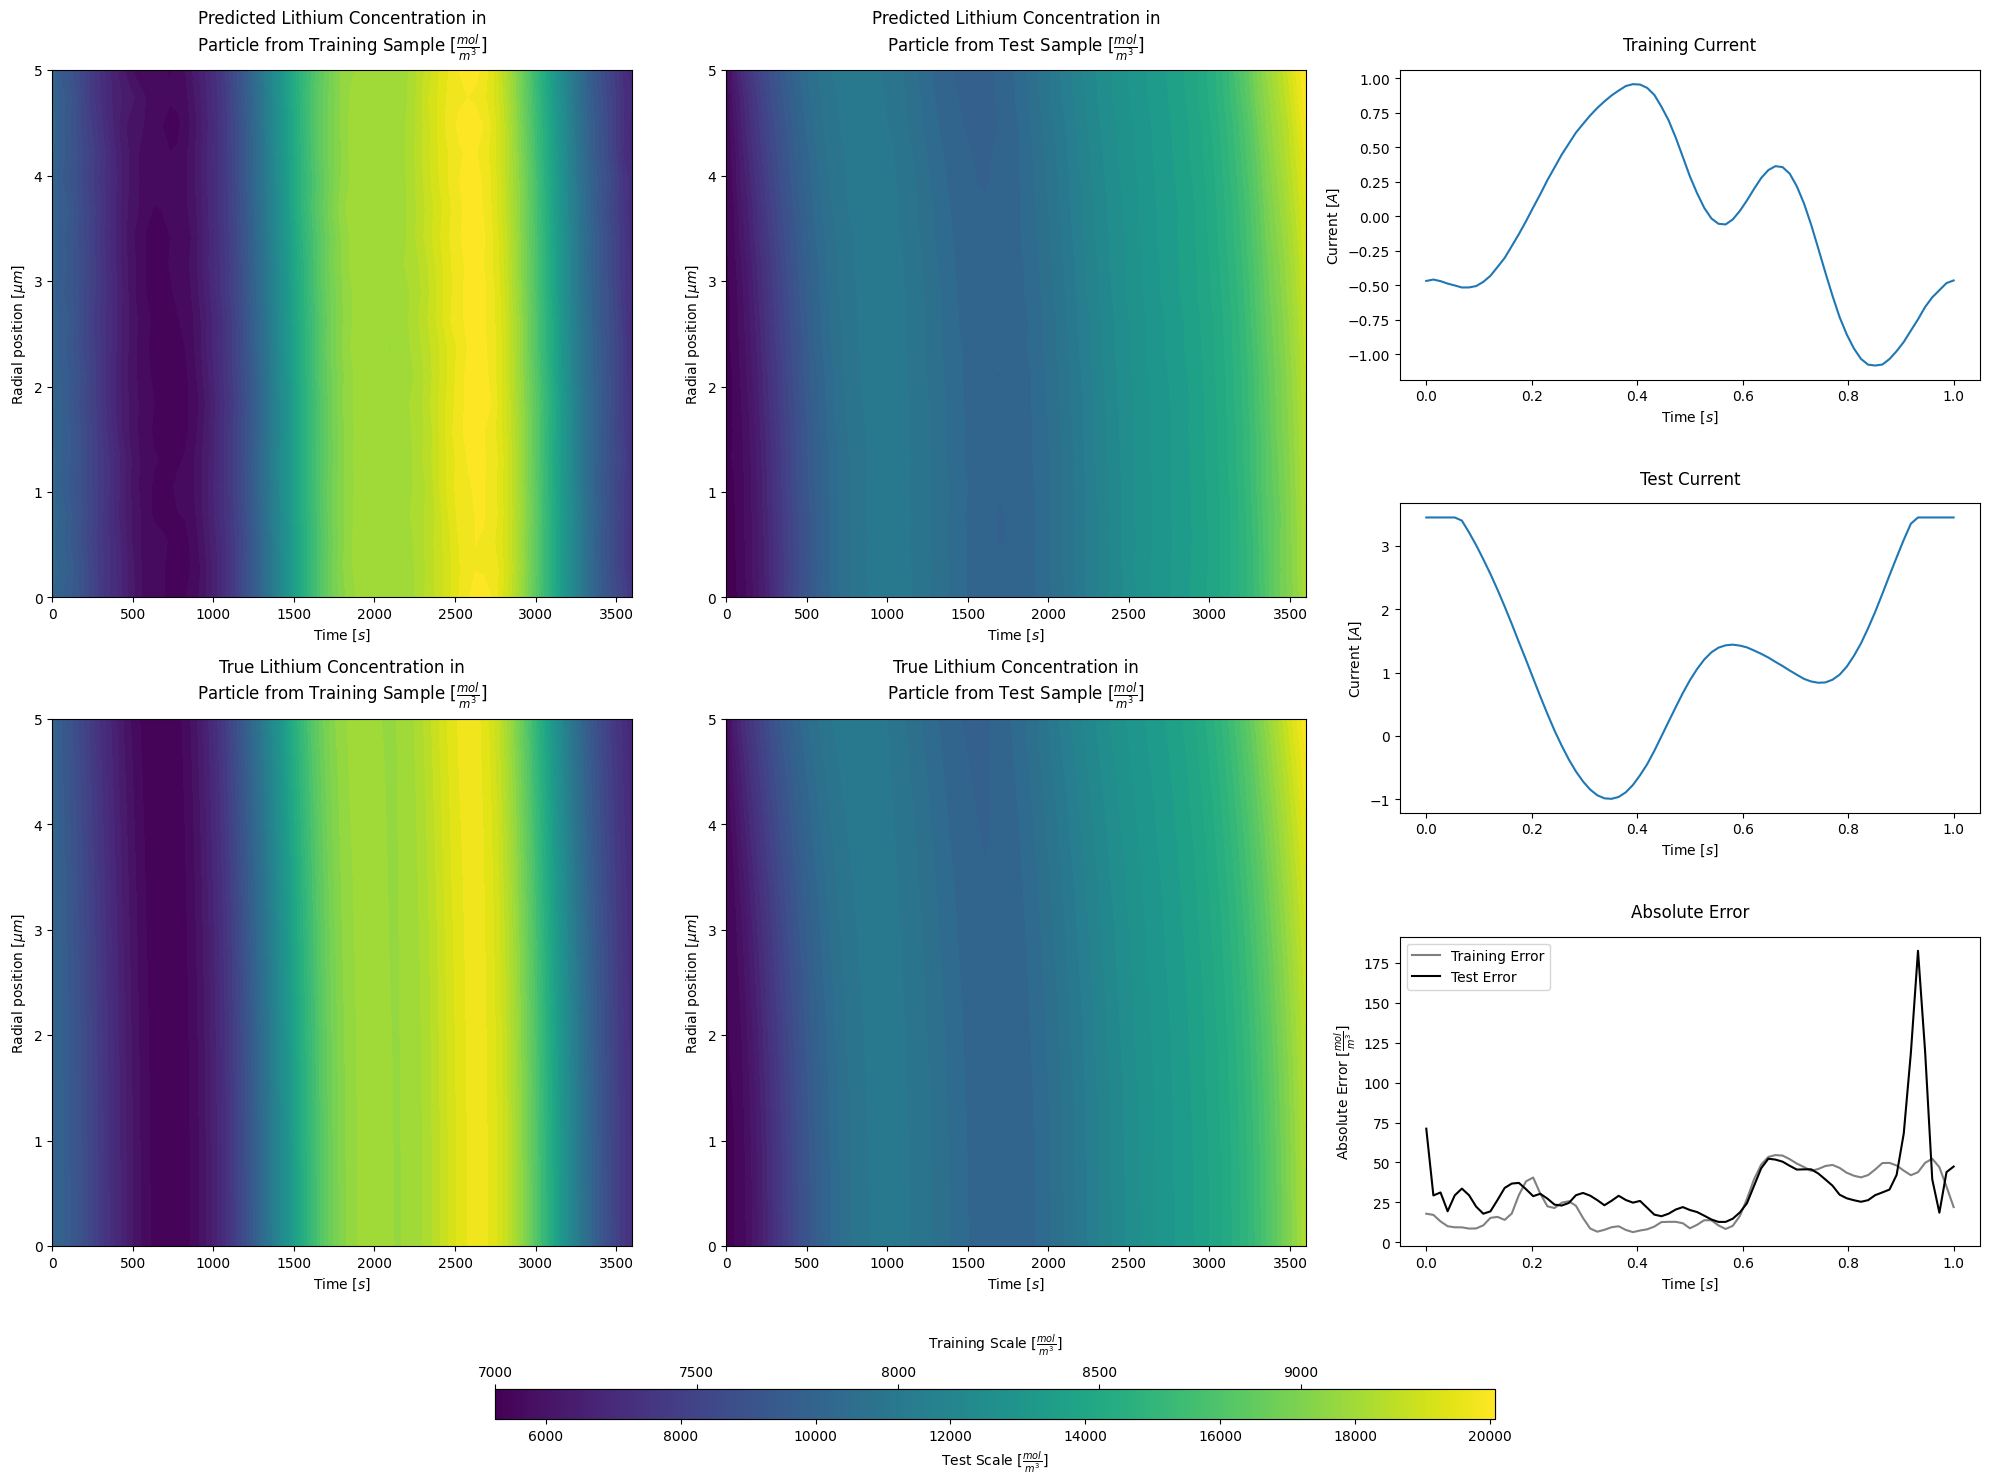

In [113]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled_anode, c_train_true_scaled_anode, c_test_pred_scaled_anode, c_test_true_scaled_anode,
                     train_I[train_idx], test_I[test_idx], t_max, Ran)

#plt.savefig(f"../figures/cape_fno/anode_CC_{N_total}_train_test.png", dpi=300, bbox_inches='tight')
plt.show()

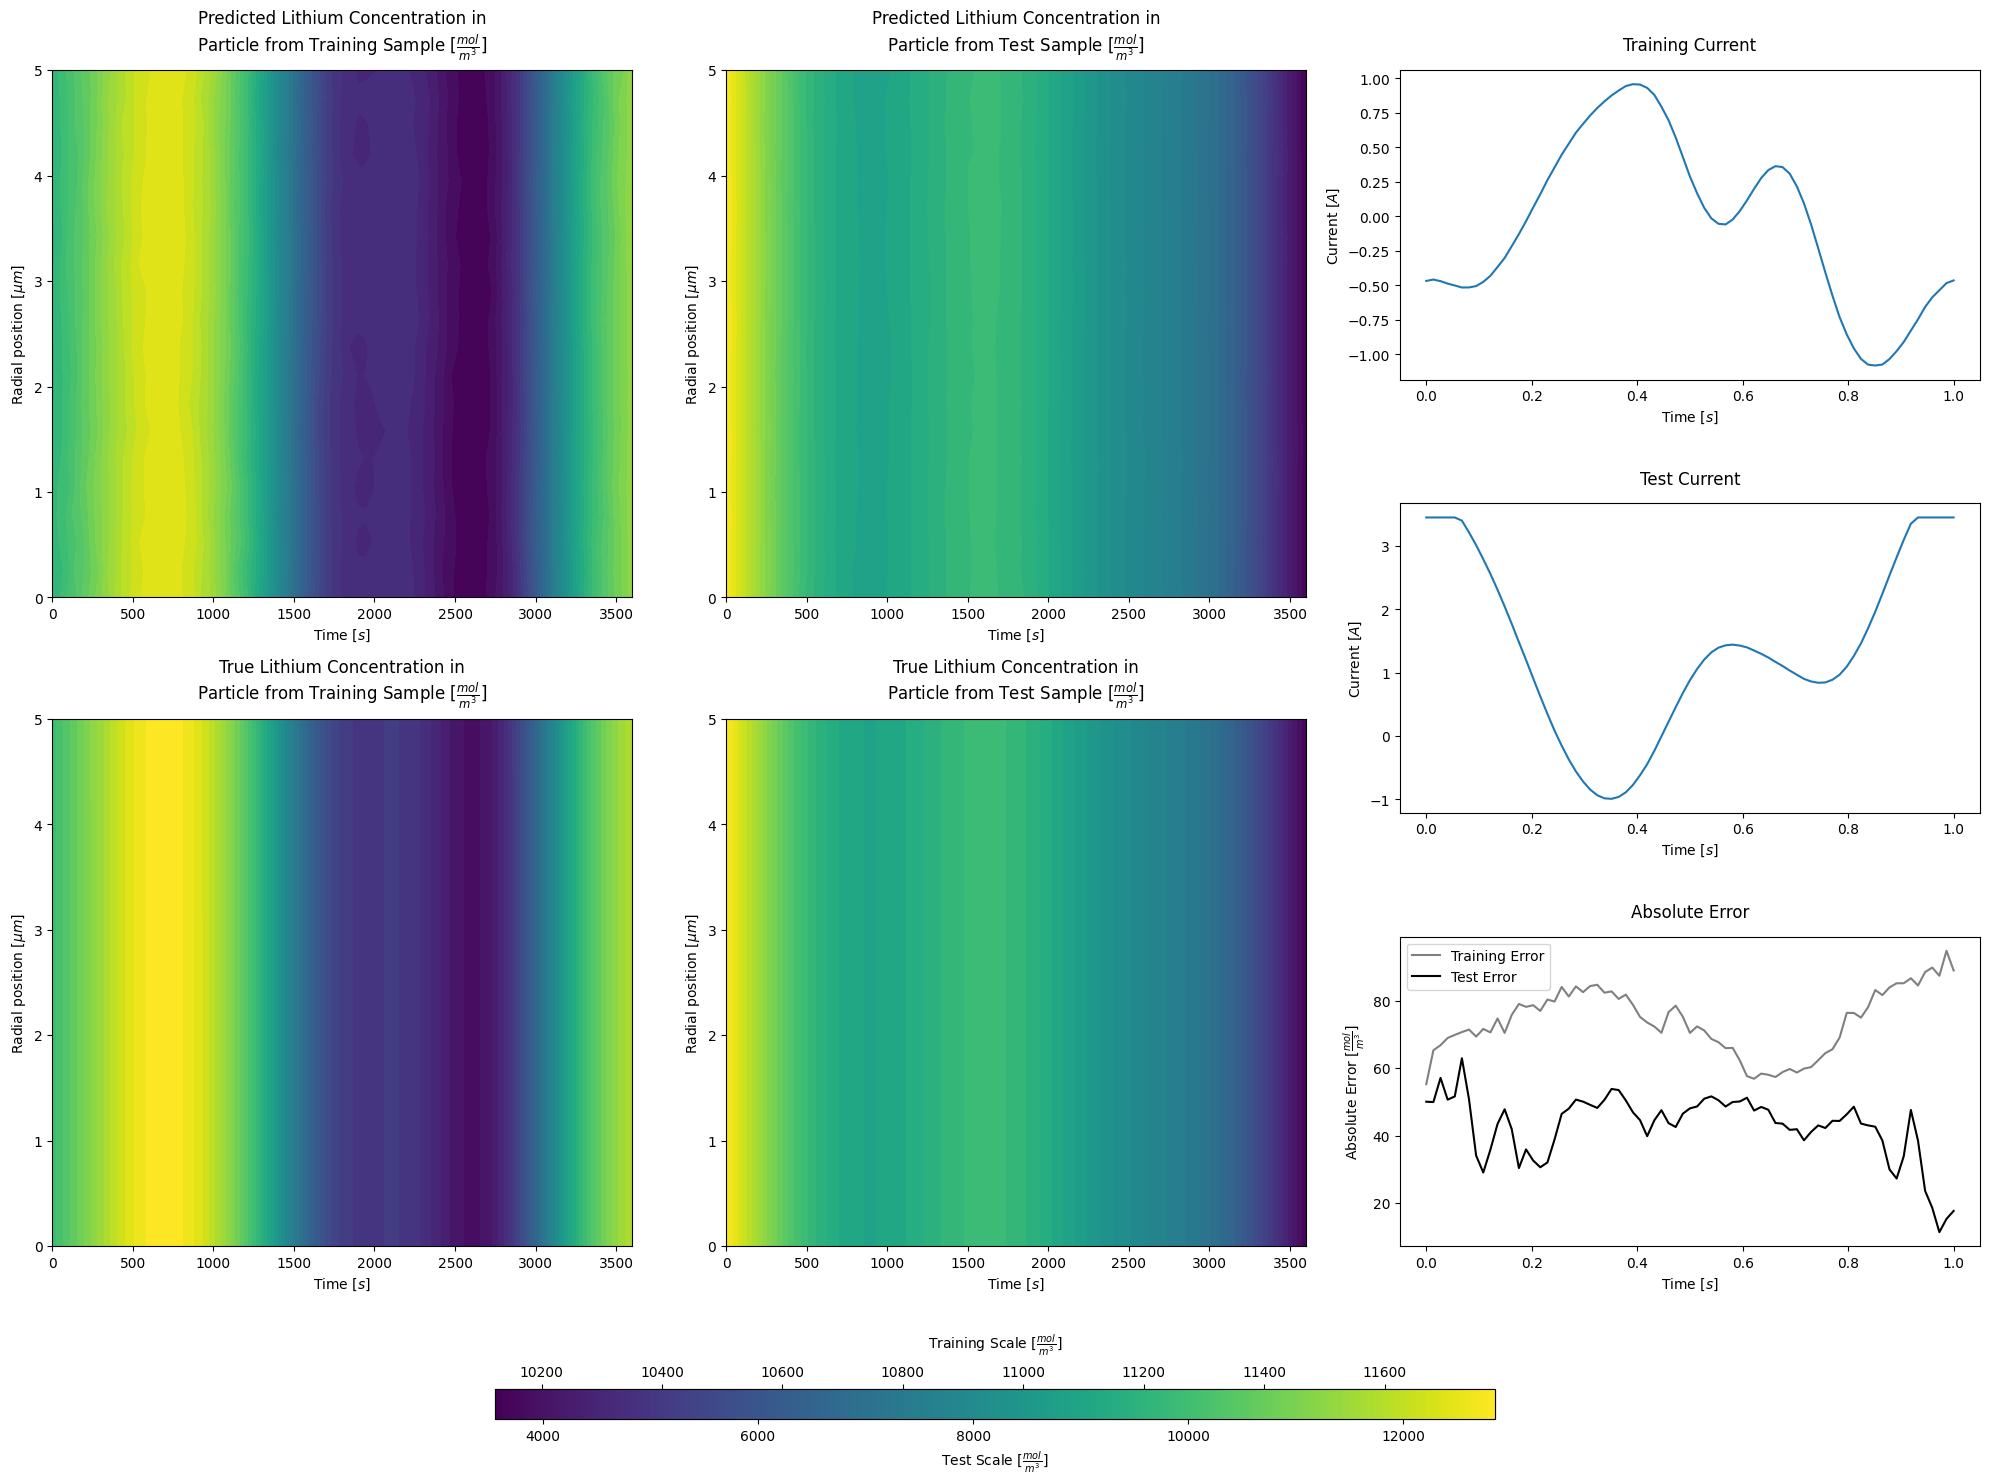

In [114]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled_cathode, c_train_true_scaled_cathode, c_test_pred_scaled_cathode, c_test_true_scaled_cathode,
                     train_I[train_idx], test_I[test_idx], t_max, Ran)

#plt.savefig(f"../figures/cape_fno/anode_CC_{N_total}_train_test.png", dpi=300, bbox_inches='tight')
plt.show()

In [115]:
# Compute V_pred and V_true using post_proc function
#from functions import post_proc
V_pred, V_true = functions.post_proc(params_bat, test_I[test_idx], c_pred_an_surf, c_true_an_surf, c_pred_ca_surf, c_true_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)

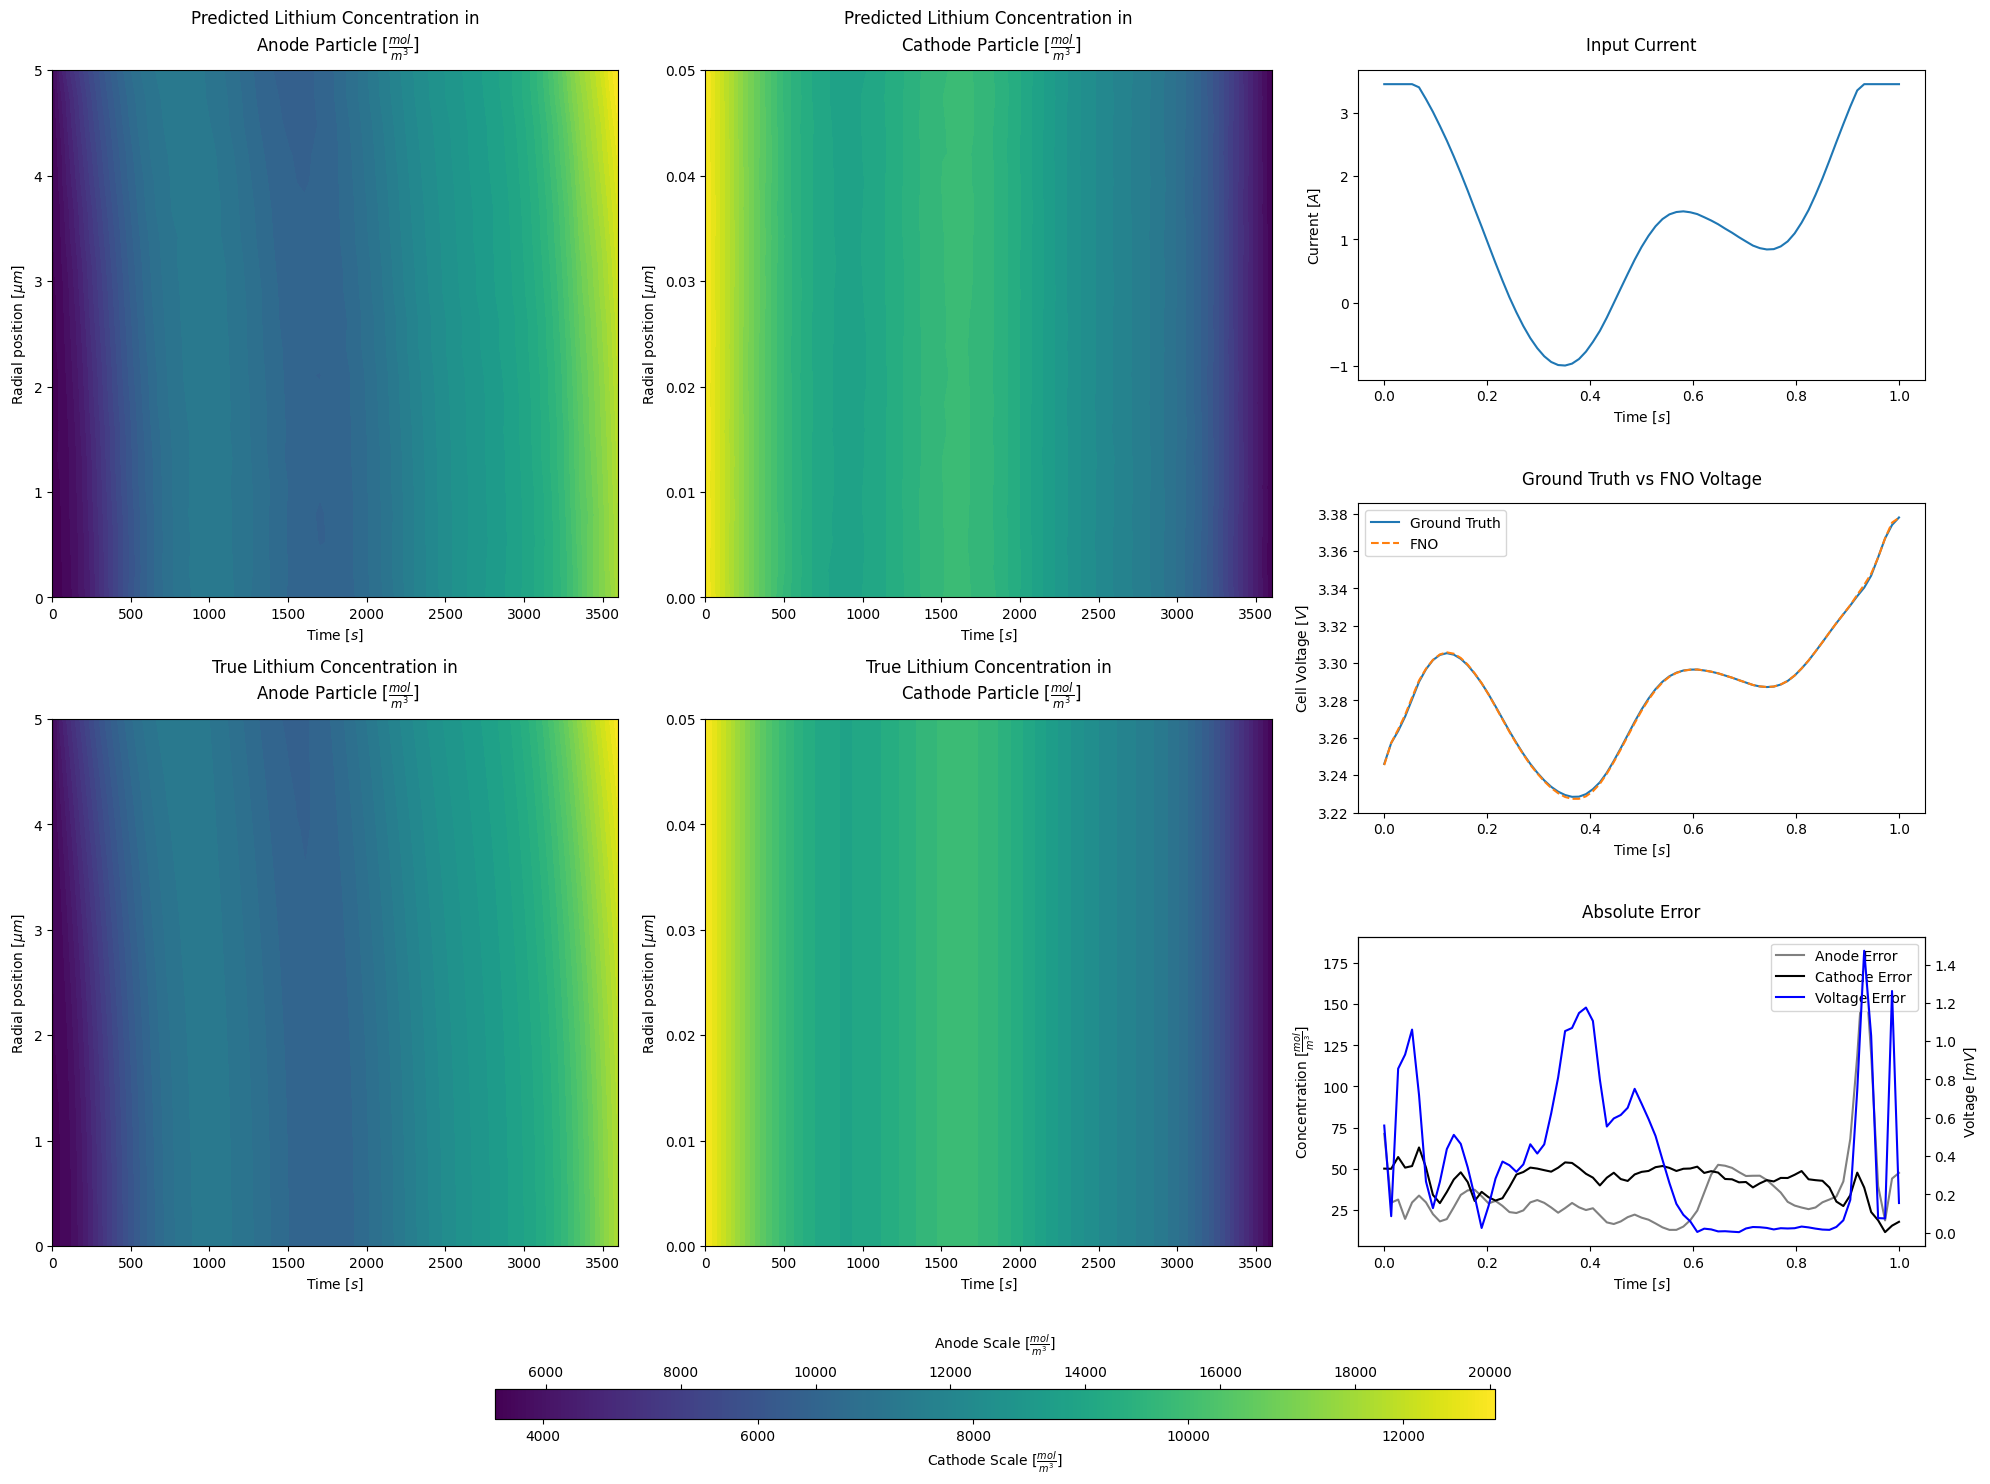

In [116]:
fig, ax = create_plot_voltage(
    c_test_pred_scaled_anode, c_test_true_scaled_anode,
    c_test_pred_scaled_cathode, c_test_true_scaled_cathode,
    test_I[test_idx], V_pred, V_true, t_max, Ran, Rca
)

plt.show()

In [137]:
import pybamm
import numpy as np

spm = pybamm.lithium_ion.SPM()
spm.events = []
# spm.initial_conditions[spm.variables["X-averaged negative particle concentration"]] = pybamm.Array(np.array(c_train_true_anode[:,0]))
# spm.initial_conditions[spm.variables["X-averaged positive particle concentration"]] = pybamm.Array(np.array(c_train_true_cathode[:,0]))
soc = test_soc[test_idx]

params_bat["Current function [A]"] = pybamm.Interpolant(t, -test_I[test_idx], pybamm.t)

sim = pybamm.Simulation(spm, parameter_values=params_bat)#, solver=fast_solver)
sol = sim.solve(initial_soc=soc, t_eval=t)

sol.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

In [121]:
c0_anode = sol["Negative particle concentration"].entries[:,0,0]
cn_target_anode = sol["Negative particle concentration"].entries[:,0,:]

c0_cathode = sol["Positive particle concentration"].entries[:,0,0]
cn_target_cathode = sol["Positive particle concentration"].entries[:,0,:]

In [122]:
np.sum(np.abs(cn_target_anode-test_cn_anode[test_idx]).flatten())

541.348981274943

In [123]:
np.allclose(test_cn_anode[test_idx].flatten(),cn_target_anode.flatten())

False

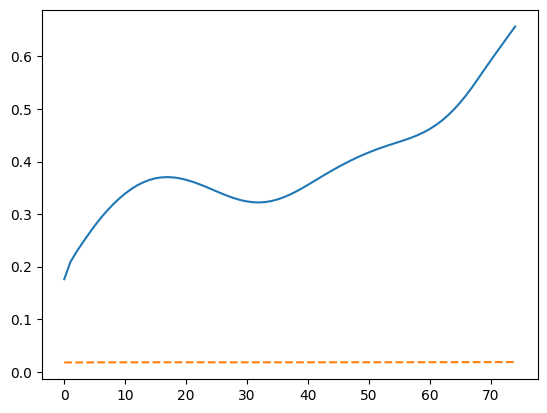

In [124]:
plt.plot(test_cn_anode[test_idx][-1,:])
plt.plot(cn_target_anode[-1,:], "--")

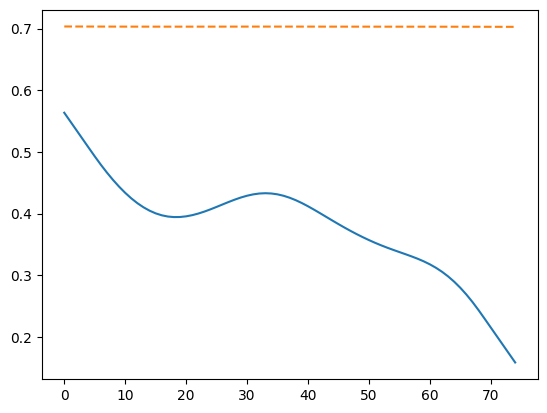

In [125]:
plt.plot(test_cn_cathode[test_idx][-1,:])
plt.plot(cn_target_cathode[-1,:], "--")